<a href="https://colab.research.google.com/github/HarshGupta959832/ANN-Classification-Churn/blob/main/IPLScorePredictionUsingDeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **IPL Score Prediction using Deep Learning**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
# Load Data
matches= pd.read_csv('matches.csv')
matches.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [ ]:
matches.tail()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
751,11347,2019,Mumbai,05/05/19,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,9,HH Pandya,Wankhede Stadium,Nanda Kishore,O Nandan,S Ravi
752,11412,2019,Chennai,07/05/19,Chennai Super Kings,Mumbai Indians,Chennai Super Kings,bat,normal,0,Mumbai Indians,0,6,AS Yadav,M. A. Chidambaram Stadium,Nigel Llong,Nitin Menon,Ian Gould
753,11413,2019,Visakhapatnam,08/05/19,Sunrisers Hyderabad,Delhi Capitals,Delhi Capitals,field,normal,0,Delhi Capitals,0,2,RR Pant,ACA-VDCA Stadium,NaN,NaN,NaN
754,11414,2019,Visakhapatnam,10/05/19,Delhi Capitals,Chennai Super Kings,Chennai Super Kings,field,normal,0,Chennai Super Kings,0,6,F du Plessis,ACA-VDCA Stadium,Sundaram Ravi,Bruce Oxenford,Chettithody Shamshuddin
755,11415,2019,Hyderabad,12/05/19,Mumbai Indians,Chennai Super Kings,Mumbai Indians,bat,normal,0,Mumbai Indians,1,0,JJ Bumrah,Rajiv Gandhi Intl. Cricket Stadium,Nitin Menon,Ian Gould,Nigel Llong


In [ ]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               756 non-null    int64 
 1   season           756 non-null    int64 
 2   city             749 non-null    object
 3   date             756 non-null    object
 4   team1            756 non-null    object
 5   team2            756 non-null    object
 6   toss_winner      756 non-null    object
 7   toss_decision    756 non-null    object
 8   result           756 non-null    object
 9   dl_applied       756 non-null    int64 
 10  winner           752 non-null    object
 11  win_by_runs      756 non-null    int64 
 12  win_by_wickets   756 non-null    int64 
 13  player_of_match  752 non-null    object
 14  venue            756 non-null    object
 15  umpire1          754 non-null    object
 16  umpire2          754 non-null    object
 17  umpire3          119 non-null    ob

In [ ]:
matches.shape

(756, 18)

In [ ]:
matches.describe()

,id,season,dl_applied,win_by_runs,win_by_wickets
count,756.000000,756.000000,756.000000,756.000000,756.000000
mean,1792.178571,2013.444444,0.025132,13.283069,3.350529
std,3464.478148,3.366895,0.156630,23.471144,3.387963
min,1.000000,2008.000000,0.000000,0.000000,0.000000
25%,189.750000,2011.000000,0.000000,0.000000,0.000000
50%,378.500000,2013.000000,0.000000,0.000000,4.000000
75%,567.250000,2016.000000,0.000000,19.000000,6.000000
max,11415.000000,2019.000000,1.000000,146.000000,10.000000


In [ ]:
delivery = pd.read_csv("deliveries.csv")
delivery.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


In [ ]:
delivery.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20543 entries, 0 to 20542
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   match_id          20543 non-null  int64 
 1   inning            20543 non-null  int64 
 2   batting_team      20543 non-null  object
 3   bowling_team      20543 non-null  object
 4   over              20543 non-null  int64 
 5   ball              20543 non-null  int64 
 6   batsman           20543 non-null  object
 7   non_striker       20543 non-null  object
 8   bowler            20543 non-null  object
 9   is_super_over     20543 non-null  int64 
 10  wide_runs         20543 non-null  int64 
 11  bye_runs          20543 non-null  int64 
 12  legbye_runs       20543 non-null  int64 
 13  noball_runs       20543 non-null  int64 
 14  penalty_runs      20543 non-null  int64 
 15  batsman_runs      20543 non-null  int64 
 16  extra_runs        20543 non-null  int64 
 17  total_runs  

In [ ]:
delivery.describe()

,match_id,inning,over,ball,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs
count,20543.000000,20543.000000,20543.000000,20543.000000,20543.000000,20543.000000,20543.000000,20543.000000,20543.000000,20543.000000,20543.000000,20543.000000,20543.000000
mean,43.998296,1.476172,10.074186,3.617680,0.000633,0.037385,0.004965,0.022489,0.004332,0.000243,1.279998,0.069415,1.349413
std,25.272098,0.502263,5.652252,1.809161,0.025149,0.247988,0.114963,0.198035,0.067146,0.034885,1.646927,0.341739,1.632087
min,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,22.000000,1.000000,5.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,44.000000,1.000000,10.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
75%,66.000000,2.000000,15.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
max,88.000000,4.000000,20.000000,9.000000,1.000000,5.000000,4.000000,5.000000,2.000000,5.000000,6.000000,5.000000,7.000000


In [ ]:
delivery.shape

(20543, 21)

In [ ]:
#merging the 2 datasets
merge = pd.merge(delivery,matches, left_on='match_id', right_on ='id')
merge.head(2)

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN


In [ ]:
merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20543 entries, 0 to 20542
Data columns (total 39 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   match_id          20543 non-null  int64 
 1   inning            20543 non-null  int64 
 2   batting_team      20543 non-null  object
 3   bowling_team      20543 non-null  object
 4   over              20543 non-null  int64 
 5   ball              20543 non-null  int64 
 6   batsman           20543 non-null  object
 7   non_striker       20543 non-null  object
 8   bowler            20543 non-null  object
 9   is_super_over     20543 non-null  int64 
 10  wide_runs         20543 non-null  int64 
 11  bye_runs          20543 non-null  int64 
 12  legbye_runs       20543 non-null  int64 
 13  noball_runs       20543 non-null  int64 
 14  penalty_runs      20543 non-null  int64 
 15  batsman_runs      20543 non-null  int64 
 16  extra_runs        20543 non-null  int64 
 17  total_runs  

In [ ]:
merge.describe()

,match_id,inning,over,ball,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,id,season,dl_applied,win_by_runs,win_by_wickets
count,20543.000000,20543.000000,20543.000000,20543.000000,20543.000000,20543.000000,20543.000000,20543.000000,20543.000000,20543.000000,20543.000000,20543.000000,20543.000000,20543.000000,20543.000000,20543.000000,20543.000000,20543.000000
mean,43.998296,1.476172,10.074186,3.617680,0.000633,0.037385,0.004965,0.022489,0.004332,0.000243,1.279998,0.069415,1.349413,43.998296,2014.073018,0.007643,12.960035,3.621282
std,25.272098,0.502263,5.652252,1.809161,0.025149,0.247988,0.114963,0.198035,0.067146,0.034885,1.646927,0.341739,1.632087,25.272098,4.216216,0.087089,26.667515,3.450257
min,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2008.000000,0.000000,0.000000,0.000000
25%,22.000000,1.000000,5.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22.000000,2008.000000,0.000000,0.000000,0.000000
50%,44.000000,1.000000,10.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,44.000000,2017.000000,0.000000,0.000000,4.000000
75%,66.000000,2.000000,15.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,66.000000,2017.000000,0.000000,14.000000,7.000000
max,88.000000,4.000000,20.000000,9.000000,1.000000,5.000000,4.000000,5.000000,2.000000,5.000000,6.000000,5.000000,7.000000,88.000000,2017.000000,1.000000,146.000000,10.000000


In [ ]:
matches.id.is_unique

True

In [ ]:
matches.set_index('id', inplace=True)
#Summary statistics of matches data
matches.describe(include = 'all')

,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
count,756.000000,749,756,756,756,756,756,756,756.000000,752,756.000000,756.000000,752,756,754,754,119
unique,NaN,32,546,15,15,15,2,3,NaN,15,NaN,NaN,226,41,61,65,25
top,NaN,Mumbai,2017-04-08,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,field,normal,NaN,Mumbai Indians,NaN,NaN,CH Gayle,Eden Gardens,HDPK Dharmasena,S Ravi,Nitin Menon
freq,NaN,101,2,101,95,98,463,743,NaN,109,NaN,NaN,21,77,73,57,10
mean,2013.444444,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.025132,NaN,13.283069,3.350529,NaN,NaN,NaN,NaN,NaN
std,3.366895,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.156630,NaN,23.471144,3.387963,NaN,NaN,NaN,NaN,NaN
min,2008.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN
25%,2011.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN
50%,2013.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,4.000000,NaN,NaN,NaN,NaN,NaN
75%,2016.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,19.000000,6.000000,NaN,NaN,NaN,NaN,NaN


In [ ]:
matches.head()

,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
id,,,,,,,,,,,,,,,,,
1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [ ]:
matches[matches.city.isnull()][['city','venue']]

,city,venue
id,,
462,NaN,Dubai International Cricket Stadium
463,NaN,Dubai International Cricket Stadium
467,NaN,Dubai International Cricket Stadium
469,NaN,Dubai International Cricket Stadium
470,NaN,Dubai International Cricket Stadium
475,NaN,Dubai International Cricket Stadium
477,NaN,Dubai International Cricket Stadium


In [ ]:
matches.city = matches.city.fillna('Dubai')

In [ ]:
matches[(matches.umpire1.isnull()) | (matches.umpire2.isnull())]

,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
id,,,,,,,,,,,,,,,,,
5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN
11413,2019,Visakhapatnam,08/05/19,Sunrisers Hyderabad,Delhi Capitals,Delhi Capitals,field,normal,0,Delhi Capitals,0,2,RR Pant,ACA-VDCA Stadium,NaN,NaN,NaN


In [ ]:
matches = matches.drop('umpire3', axis = 1)
#city has 33 distinct values while we have 35 venues.
#Let's find out venues grouped by cities to see which cities have multiple venues

city_venue = matches.groupby(['city','venue']).count()['season']
city_venue_df = pd.DataFrame(city_venue)
city_venue_df

season
city           venue                                                     
Abu Dhabi      Sheikh Zayed Stadium                                     7
Ahmedabad      Sardar Patel Stadium, Motera                            12
Bangalore      M Chinnaswamy Stadium                                   66
Bengaluru      M Chinnaswamy Stadium                                    7
               M. Chinnaswamy Stadium                                   7
Bloemfontein   OUTsurance Oval                                          2
Cape Town      Newlands                                                 7
Centurion      SuperSport Park                                         12
Chandigarh     Punjab Cricket Association IS Bindra Stadium, M...      11
               Punjab Cricket Association Stadium, Mohali              35
Chennai        M. A. Chidambaram Stadium                                8
               MA Chidambaram Stadium, Chepauk                         49
Cuttack        Barabati Stadium                                         7
Delhi          Feroz Shah Kotla                                        67
               Feroz Shah Kotla Ground                                  7
Dharamsala     Himachal Pradesh Cricket Association Stadium             9
Dubai          Dubai International Cricket Stadium                      7
Durban         Kingsmead                                               15
East London    Buffalo Park                                             3
Hyderabad      Rajiv Gandhi International Stadium, Uppal               56
               Rajiv Gandhi Intl. Cricket Stadium                       8
Indore         Holkar Cricket Stadium                                   9
Jaipur         Sawai Mansingh Stadium                                  47
Johannesburg   New Wanderers Stadium                                    8
Kanpur         Green Park                                               4
Kimberley      De Beers Diamond Oval                                    3
Kochi          Nehru Stadium                                            5
Kolkata        Eden Gardens                                            77
Mohali         IS Bindra Stadium                                        7
               Punjab Cricket Association IS Bindra Stadium, M...       3
Mumbai         Brabourne Stadium                                       11
               Dr DY Patil Sports Academy                              17
               Wankhede Stadium                                        73
Nagpur         Vidarbha Cricket Association Stadium, Jamtha             3
Port Elizabeth St George's Park                                         7
Pune           Maharashtra Cricket Association Stadium                 21
               Subrata Roy Sahara Stadium                              17
Raipur         Shaheed Veer Narayan Singh International Stadium         6
Rajkot         Saurashtra Cricket Association Stadium                  10
Ranchi         JSCA International Stadium Complex                       7
Sharjah        Sharjah Cricket Stadium                                  6
Visakhapatnam  ACA-VDCA Stadium                                         2
               Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Sta...      11

(array([ 0., 10., 20., 30., 40., 50., 60., 70., 80.]),
 [Text(0, 0.0, '0'),
  Text(0, 10.0, '10'),
  Text(0, 20.0, '20'),
  Text(0, 30.0, '30'),
  Text(0, 40.0, '40'),
  Text(0, 50.0, '50'),
  Text(0, 60.0, '60'),
  Text(0, 70.0, '70'),
  Text(0, 80.0, '80')])

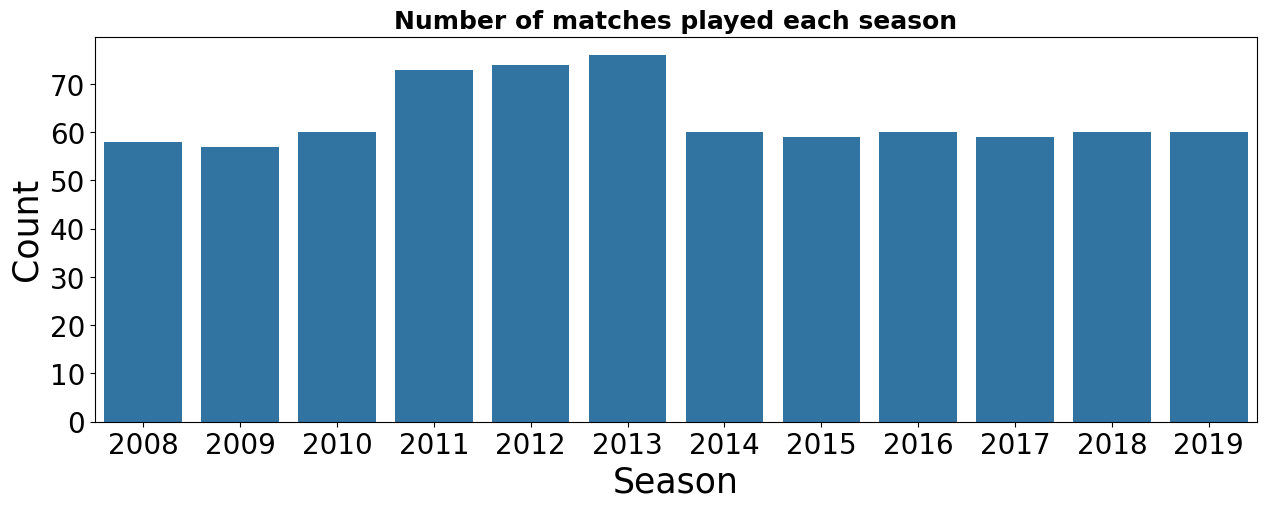

In [ ]:
plt.figure(figsize=(15,5))
sns.countplot(x='season', data = matches)
plt.title("Number of matches played each season",fontsize=18,fontweight="bold")
plt.ylabel("Count", size = 25)
plt.xlabel("Season", size = 25)
plt.xticks(size = 20)
plt.yticks(size = 20)

(array([ 0.,  2.,  4.,  6.,  8., 10., 12.]),
 [Text(0, 0.0, '0'),
  Text(0, 2.0, '2'),
  Text(0, 4.0, '4'),
  Text(0, 6.0, '6'),
  Text(0, 8.0, '8'),
  Text(0, 10.0, '10'),
  Text(0, 12.0, '12')])

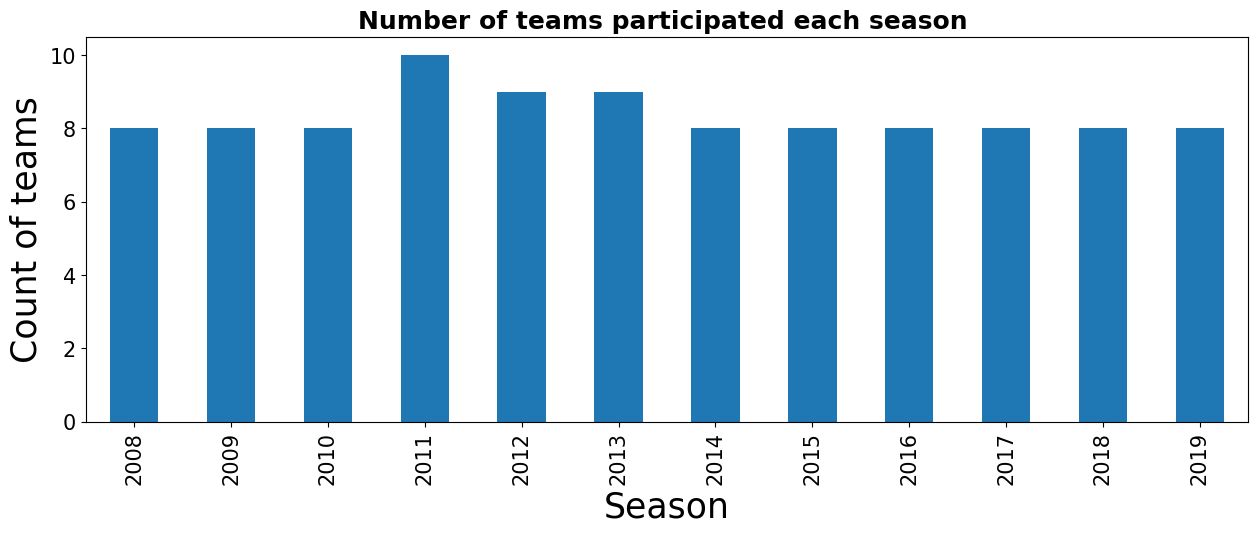

In [ ]:
matches.groupby('season')['team1'].nunique().plot(kind = 'bar', figsize=(15,5))
plt.title("Number of teams participated each season ",fontsize=18,fontweight="bold")
plt.ylabel("Count of teams", size = 25)
plt.xlabel("Season", size = 25)
plt.xticks(size = 15)
plt.yticks(size = 15)

Text(0.5, 0, 'Frequency')

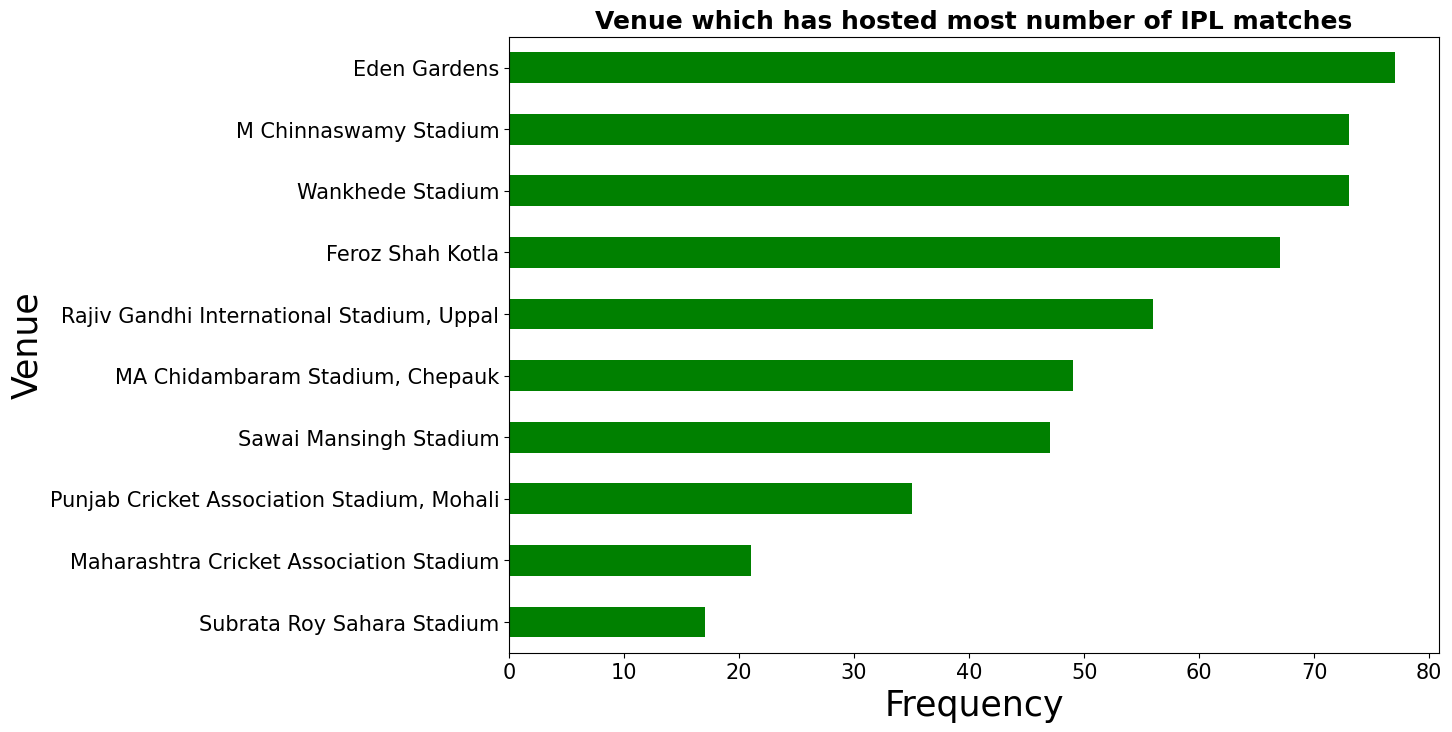

In [ ]:
matches.venue.value_counts().sort_values(ascending = True).tail(10).plot(kind = 'barh',figsize=(12,8), fontsize=15, color='green')
plt.title("Venue which has hosted most number of IPL matches",fontsize=18,fontweight="bold")
plt.ylabel("Venue", size = 25)
plt.xlabel("Frequency", size = 25)


In [ ]:
#creating a dataframe with season and winner columns
winning_teams = matches[['season','winner']]

In [ ]:
#dictionaries to get winners to each season
winners_team = {}
for i in sorted(winning_teams.season.unique()):
    winners_team[i] = winning_teams[winning_teams.season == i]['winner'].tail(1).values[0]

winners_of_IPL = pd.Series(winners_team)
winners_of_IPL = pd.DataFrame(winners_of_IPL, columns=['team'])

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, 'Mumbai Indians'),
  Text(0, 1, 'Chennai Super Kings'),
  Text(0, 2, 'Kolkata Knight Riders'),
  Text(0, 3, 'Rajasthan Royals'),
  Text(0, 4, 'Deccan Chargers'),
  Text(0, 5, 'Sunrisers Hyderabad')])

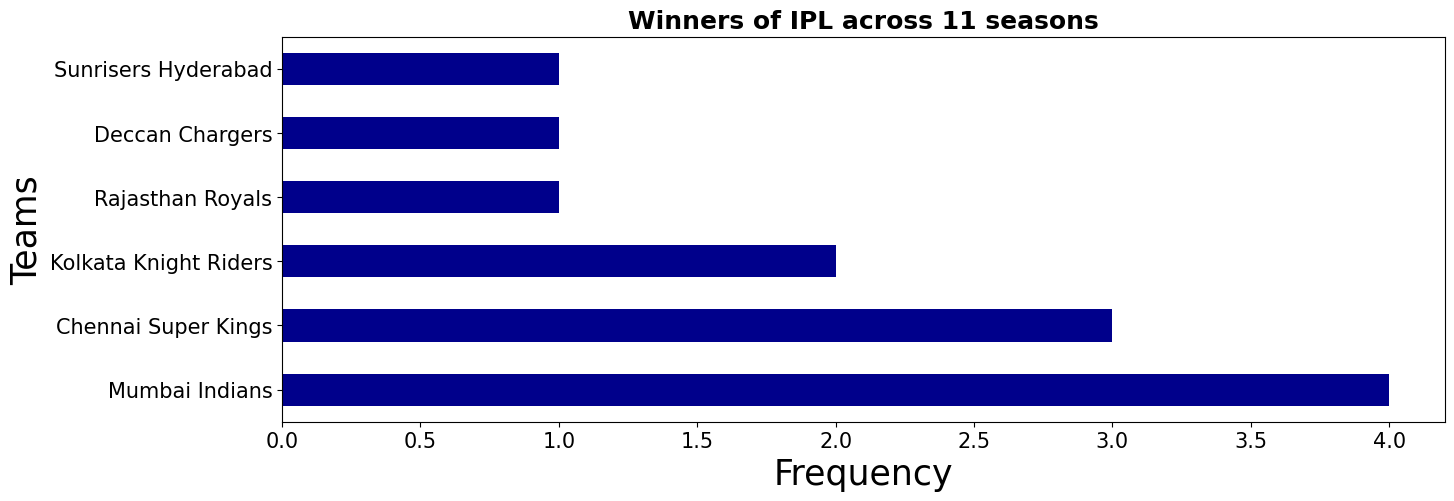

In [ ]:
winners_of_IPL['team'].value_counts().plot(kind = 'barh', figsize = (15,5), color = 'darkblue')
plt.title("Winners of IPL across 11 seasons",fontsize=18,fontweight="bold")
plt.ylabel("Teams", size = 25)
plt.xlabel("Frequency", size = 25)
plt.xticks(size = 15)
plt.yticks(size = 15)

Text(0.5, 1.0, 'Decision taken by captains after winning tosses')

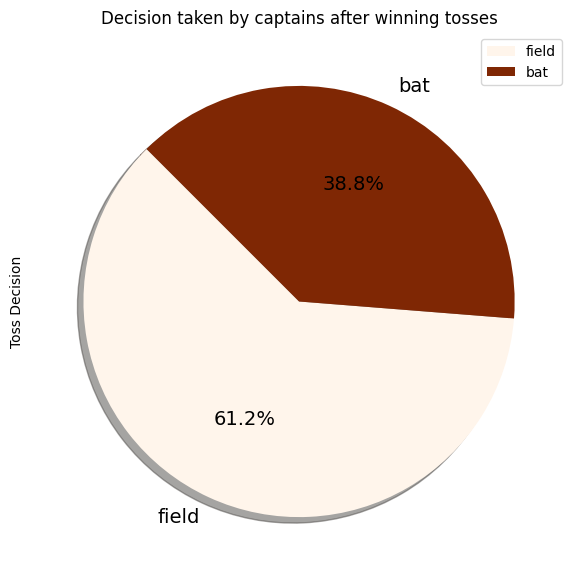

In [ ]:
matches['toss_decision'].value_counts().plot(kind='pie', fontsize=14, autopct='%3.1f%%',
                                               figsize=(10,7), shadow=True, startangle=135, legend=True, cmap='Oranges')

plt.ylabel('Toss Decision')
plt.title('Decision taken by captains after winning tosses')

Text(0, 0.5, 'Frequency')

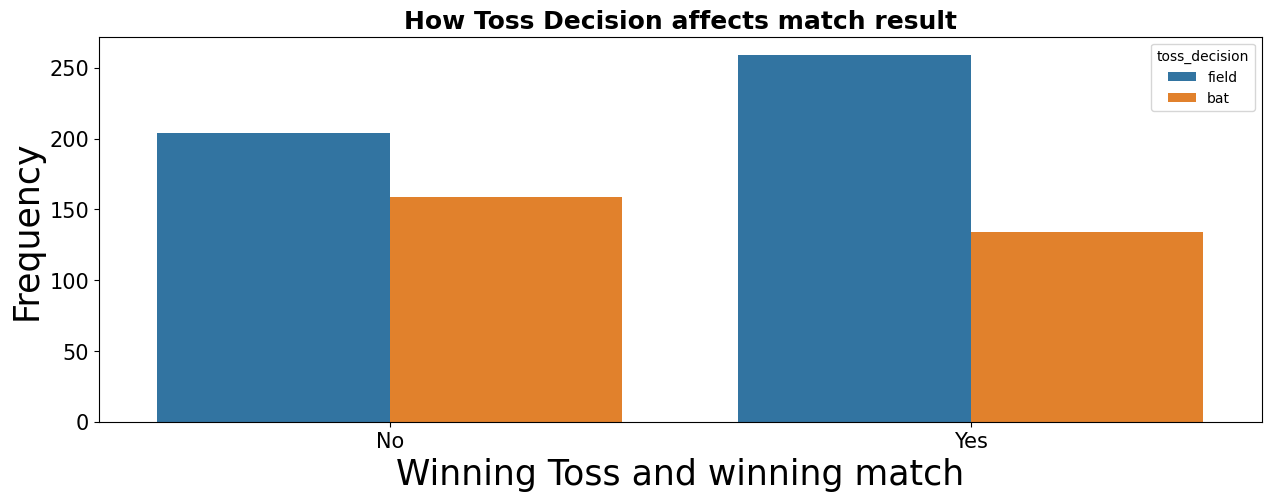

In [ ]:
matches['toss_win_game_win'] = np.where((matches.toss_winner == matches.winner),'Yes','No')
plt.figure(figsize = (15,5))
sns.countplot(x='toss_win_game_win', data=matches, hue = 'toss_decision')
plt.title("How Toss Decision affects match result", fontsize=18,fontweight="bold")
plt.xticks(size = 15)
plt.yticks(size = 15)
plt.xlabel("Winning Toss and winning match", fontsize = 25)
plt.ylabel("Frequency", fontsize = 25)

Text(0, 0.5, 'Count')

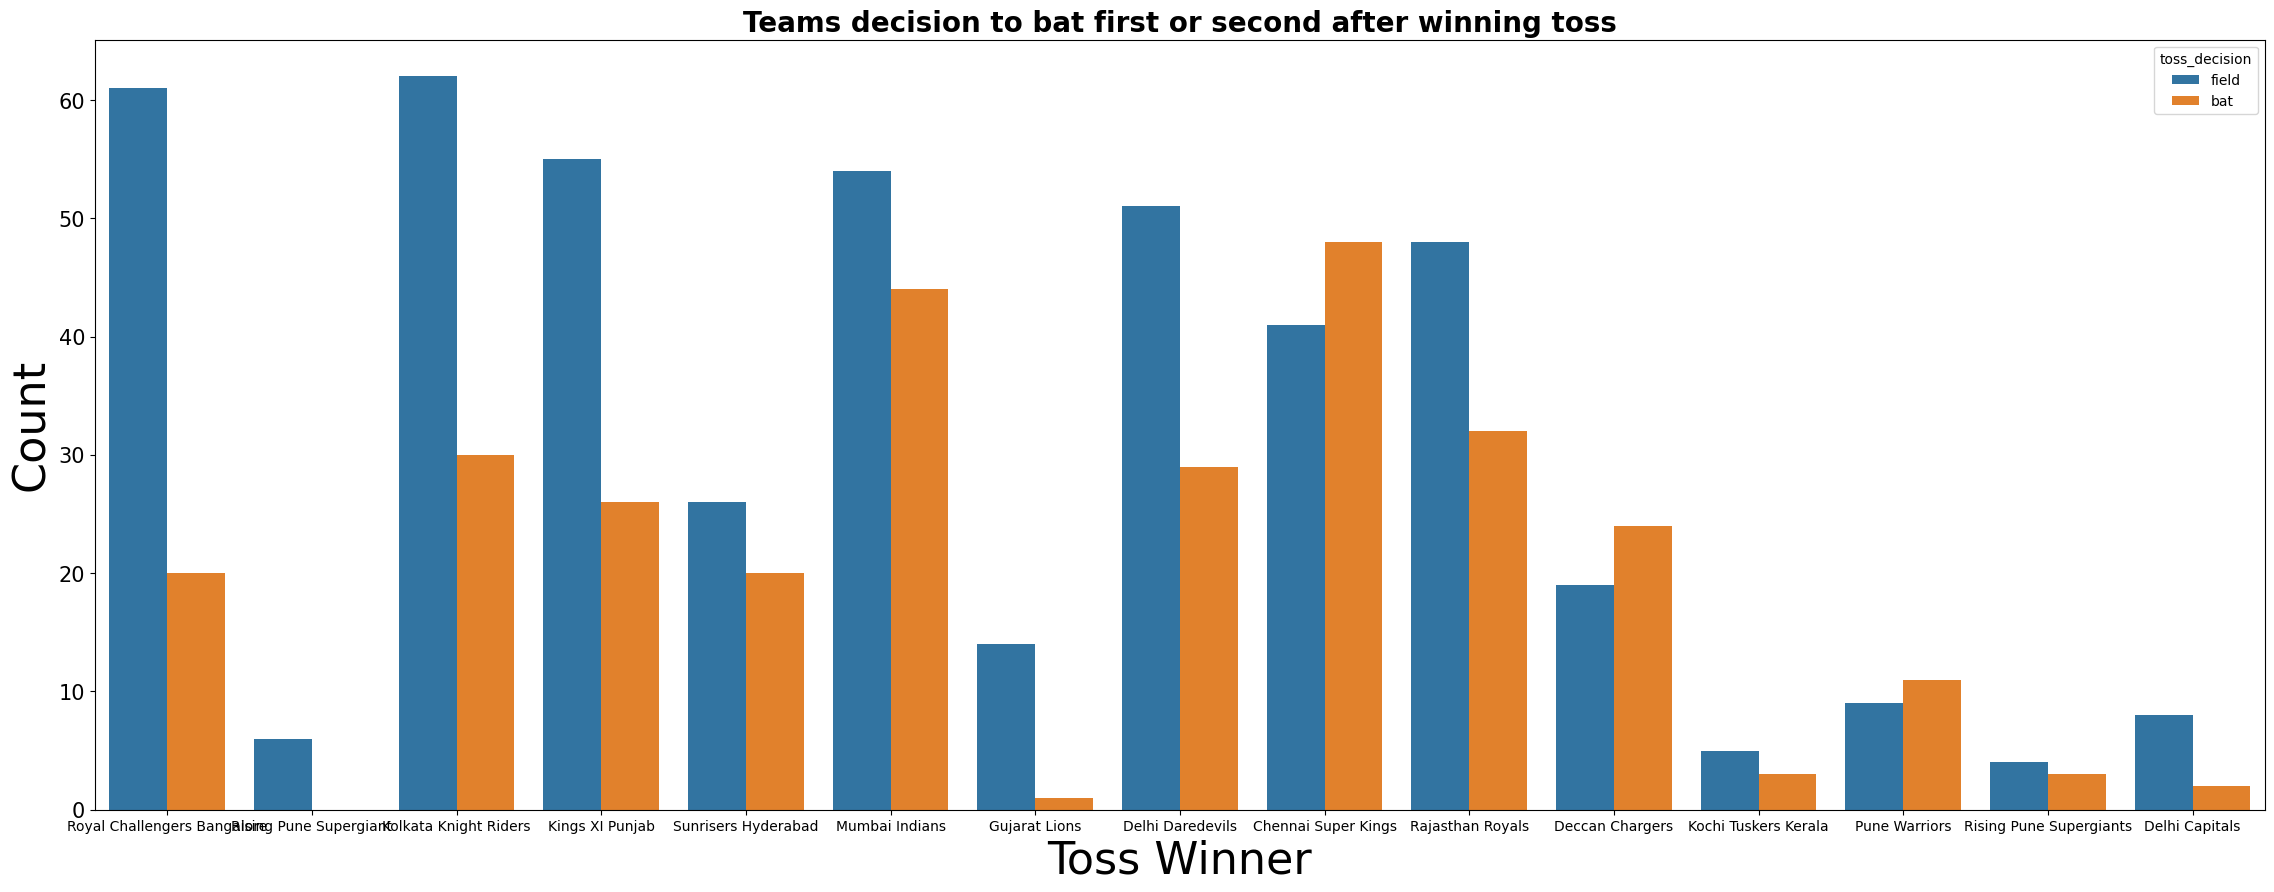

In [ ]:
plt.figure(figsize = (28,10))
sns.countplot(x='toss_winner', data = matches, hue = 'toss_decision')
plt.title("Teams decision to bat first or second after winning toss", size = 20, fontweight = 'bold')
plt.xticks(size = 10)
plt.yticks(size = 15)
plt.xlabel("Toss Winner", size = 32)
plt.ylabel("Count", size = 32)

Text(0.5, 0, 'Players')

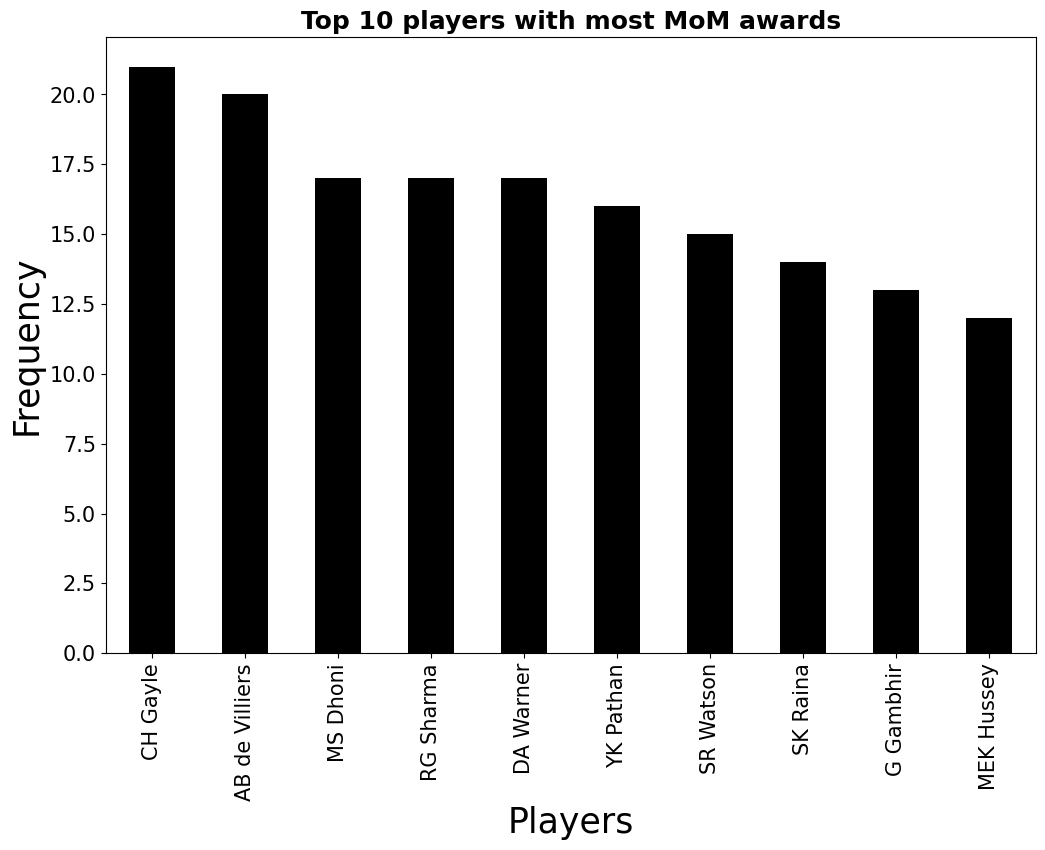

In [ ]:
# MOM = Man Of the Match
MoM= matches['player_of_match'].value_counts()
MoM.head(10).plot(kind = 'bar',figsize=(12,8), fontsize=15, color='black')
plt.title("Top 10 players with most MoM awards",fontsize=18,fontweight="bold")
plt.ylabel("Frequency", size = 25)
plt.xlabel("Players", size = 25)

/tmp/ipykernel_2045/490901199.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_matches['win_batting_first'] = np.where((new_matches.win_by_runs > 0), 'Yes', 'No')


Text(0, 0.5, 'Venue')

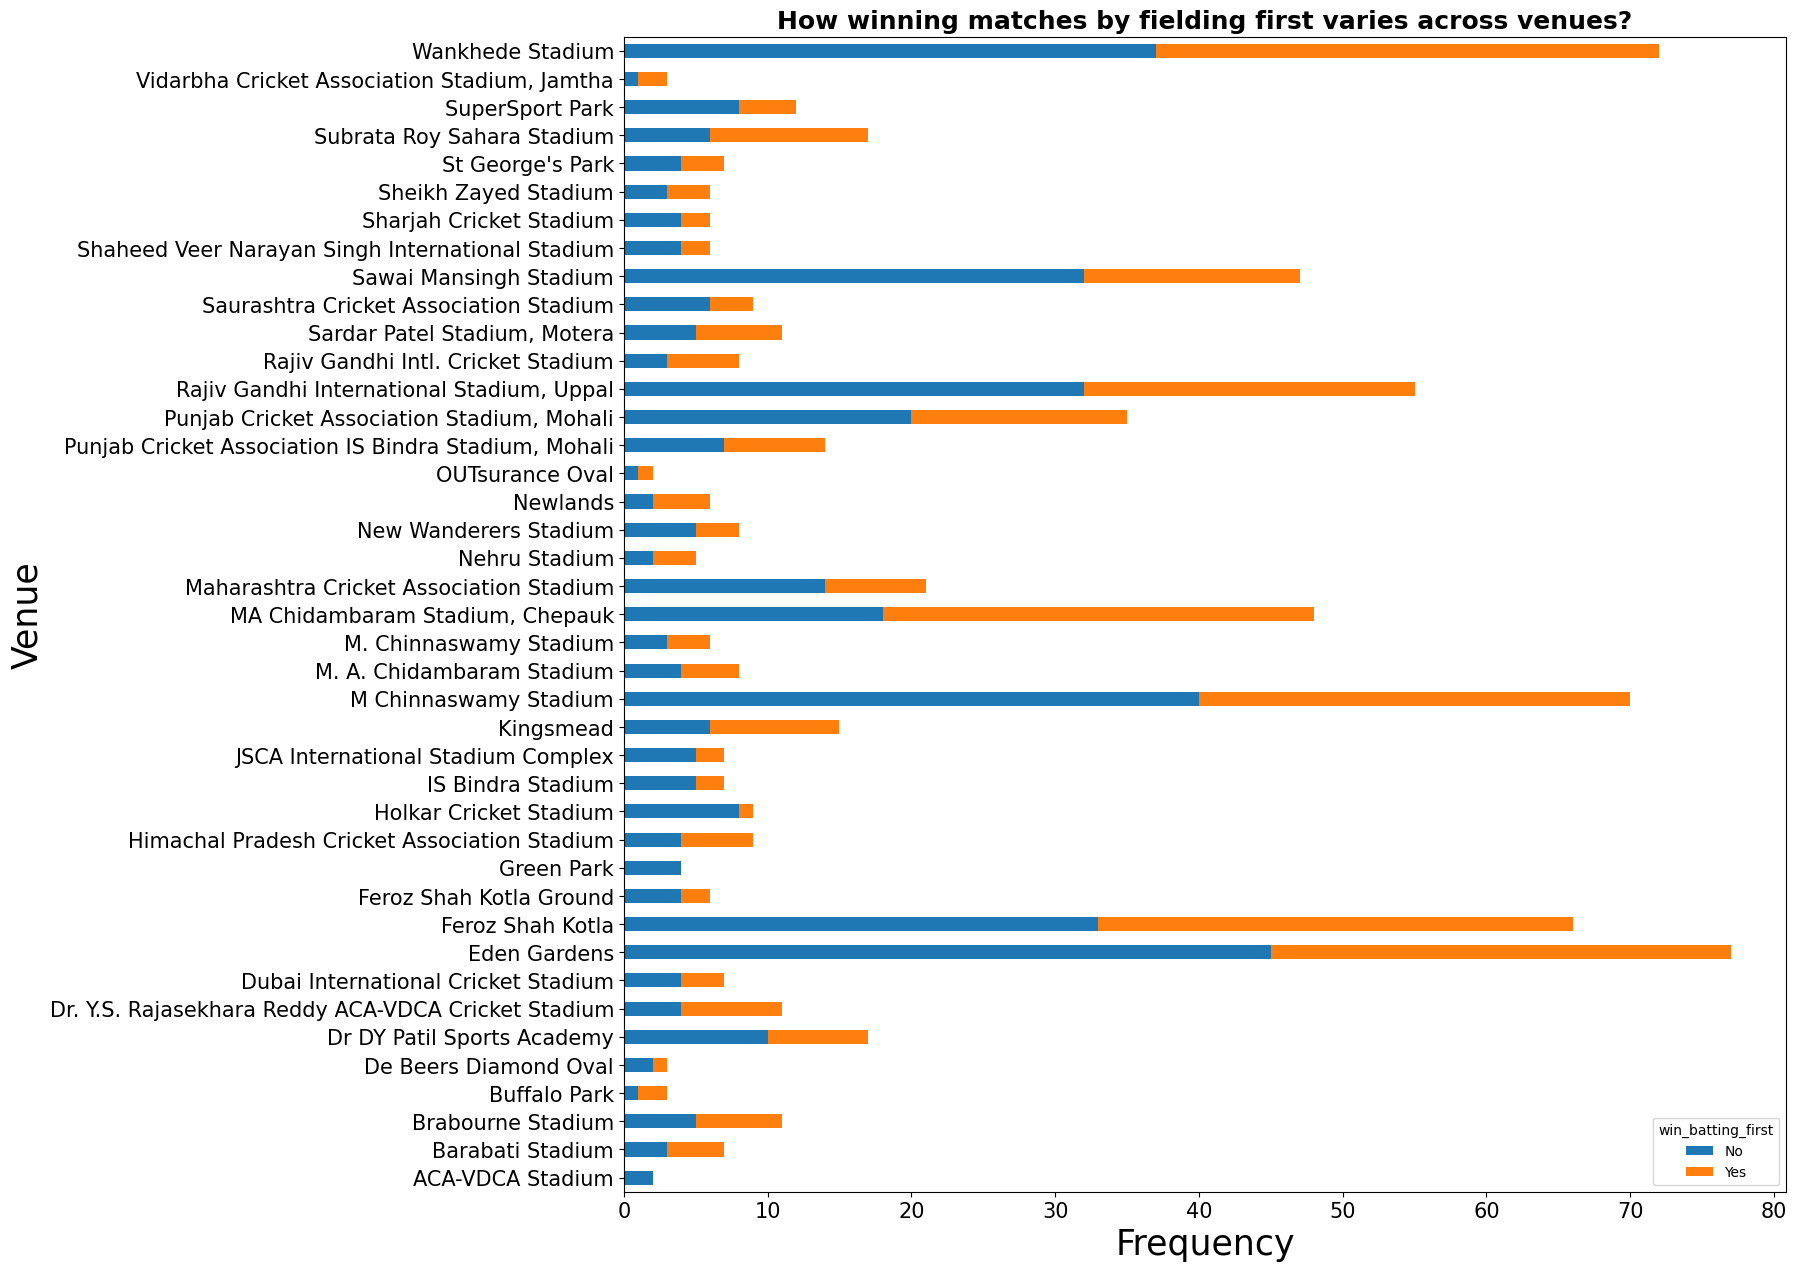

In [ ]:
new_matches = matches[matches['result'] == 'normal']   #taking all those matches where result is normal and creating a new dataframe
new_matches['win_batting_first'] = np.where((new_matches.win_by_runs > 0), 'Yes', 'No')
new_matches.groupby('venue')['win_batting_first'].value_counts().unstack().plot(kind = 'barh', stacked = True,
                                                                               figsize=(15,15))
plt.title("How winning matches by fielding first varies across venues?", fontsize=18,fontweight="bold")
plt.xticks(size = 15)
plt.yticks(size = 15)
plt.xlabel("Frequency", fontsize = 25)
plt.ylabel("Venue", fontsize = 25)

Text(0, 0.5, 'Count')

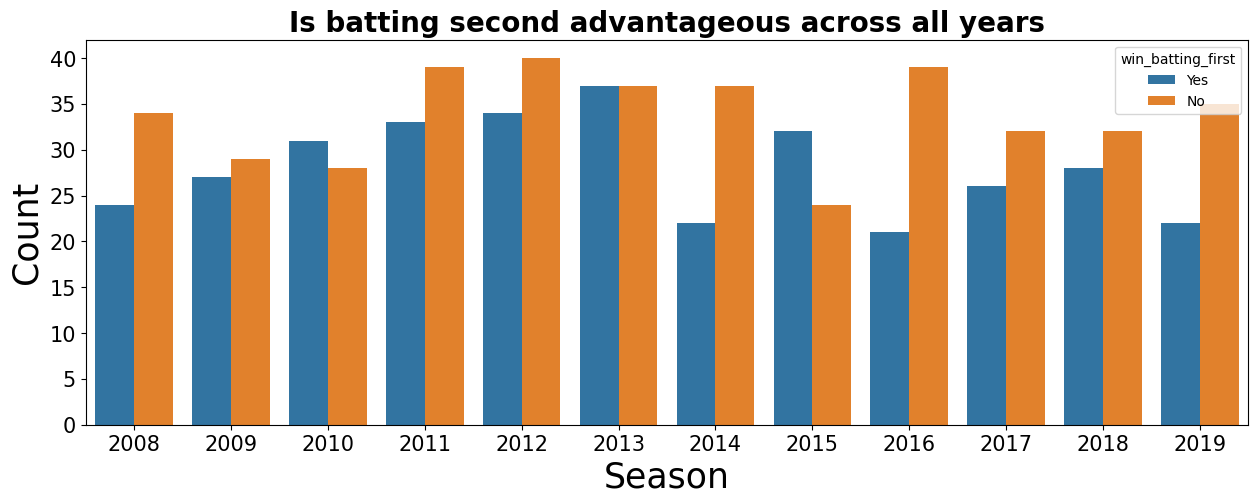

In [ ]:
plt.figure(figsize = (15,5))
sns.countplot(x='season', data = new_matches, hue = 'win_batting_first')
plt.title("Is batting second advantageous across all years", fontsize=20,fontweight="bold")
plt.xticks(size = 15)
plt.yticks(size = 15)
plt.xlabel("Season", fontsize = 25)
plt.ylabel("Count", fontsize = 25)

(array([ 6000.,  8000., 10000., 12000., 14000., 16000., 18000., 20000.]),
 [Text(0, 6000.0, '6000'),
  Text(0, 8000.0, '8000'),
  Text(0, 10000.0, '10000'),
  Text(0, 12000.0, '12000'),
  Text(0, 14000.0, '14000'),
  Text(0, 16000.0, '16000'),
  Text(0, 18000.0, '18000'),
  Text(0, 20000.0, '20000')])

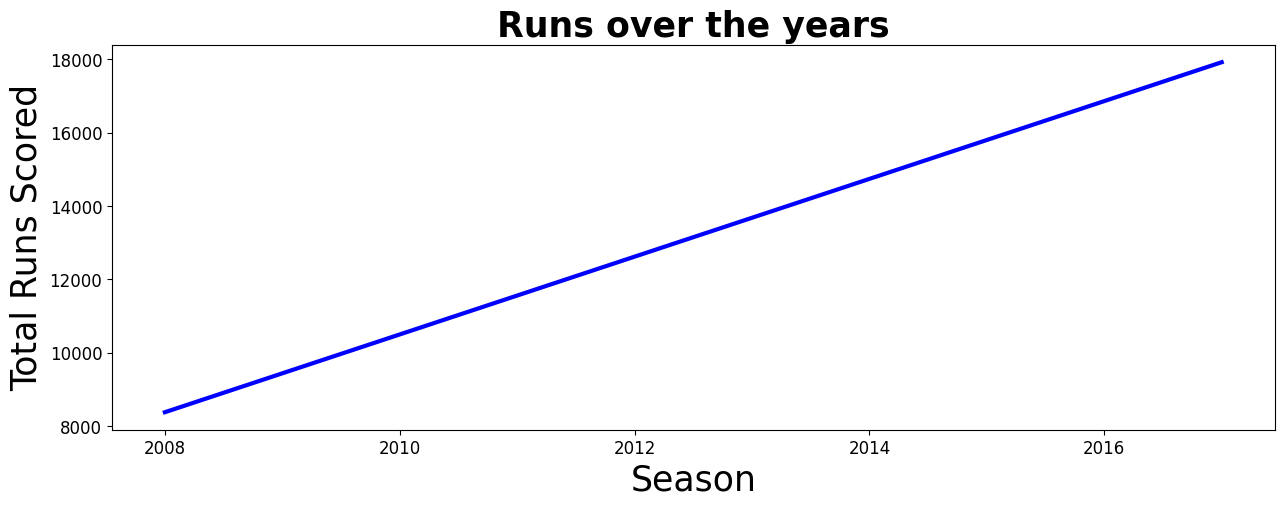

In [ ]:
merge.groupby('season')['batsman_runs'].sum().plot(kind = 'line', linewidth = 3, figsize =(15,5),
                                                                                             color = 'blue')
plt.title("Runs over the years",fontsize= 25, fontweight = 'bold')
plt.xlabel("Season", size = 25)
plt.ylabel("Total Runs Scored", size = 25)
plt.xticks(size = 12)
plt.yticks(size = 12)

(array([  0., 100., 200., 300., 400., 500., 600., 700., 800., 900.]),
 [Text(0, 0.0, '0'),
  Text(0, 100.0, '100'),
  Text(0, 200.0, '200'),
  Text(0, 300.0, '300'),
  Text(0, 400.0, '400'),
  Text(0, 500.0, '500'),
  Text(0, 600.0, '600'),
  Text(0, 700.0, '700'),
  Text(0, 800.0, '800'),
  Text(0, 900.0, '900')])

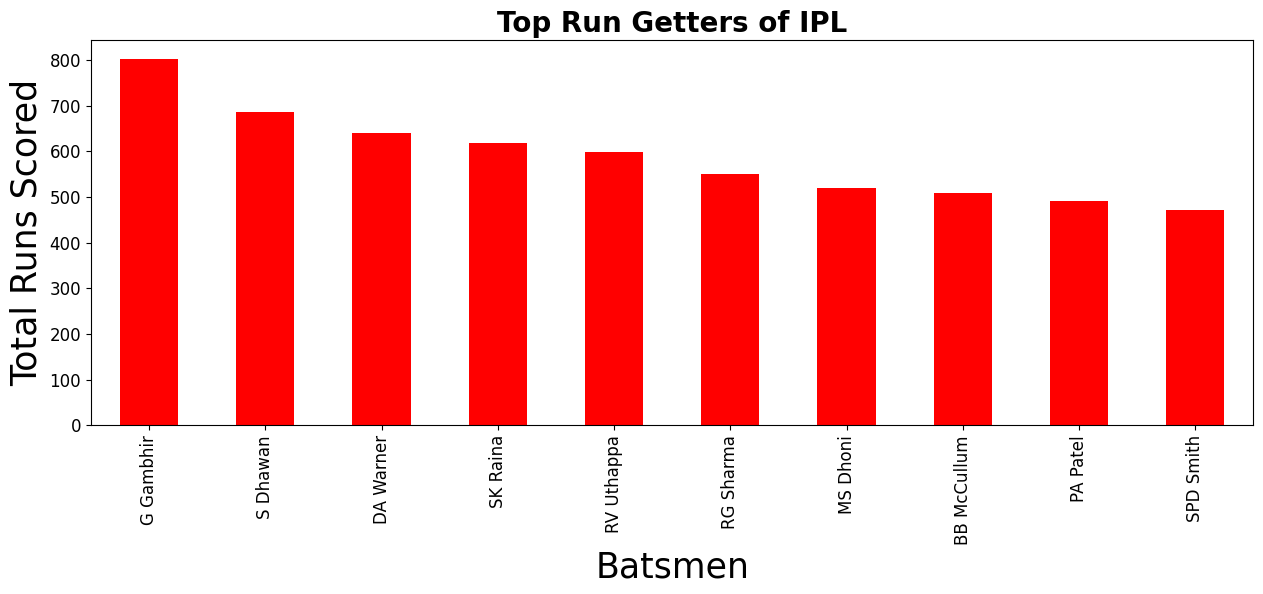

In [ ]:
#let's plot the top 10 run getter so far in IPL
merge.groupby('batsman')['batsman_runs'].sum().sort_values(ascending = False).head(10).plot(kind = 'bar', color = 'red',
                                                                                            figsize = (15,5))
plt.title("Top Run Getters of IPL", fontsize = 20, fontweight = 'bold')
plt.xlabel("Batsmen", size = 25)
plt.ylabel("Total Runs Scored", size = 25)
plt.xticks(size = 12)
plt.yticks(size = 12)

(array([  0., 100., 200., 300., 400., 500., 600., 700., 800.]),
 [Text(0, 0.0, '0'),
  Text(0, 100.0, '100'),
  Text(0, 200.0, '200'),
  Text(0, 300.0, '300'),
  Text(0, 400.0, '400'),
  Text(0, 500.0, '500'),
  Text(0, 600.0, '600'),
  Text(0, 700.0, '700'),
  Text(0, 800.0, '800')])

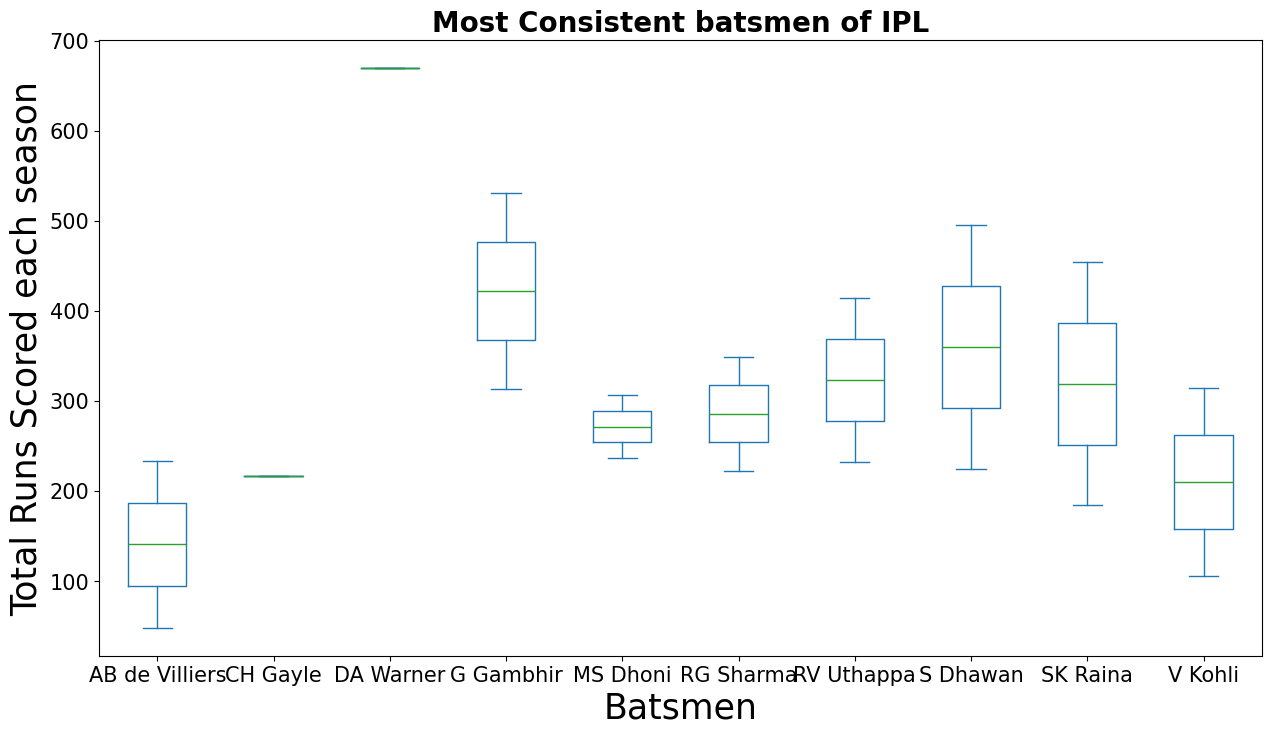

In [ ]:
consistent_batsman = merge[merge.batsman.isin(['SK Raina', 'V Kohli','RG Sharma','G Gambhir',
                                            'RV Uthappa', 'S Dhawan','CH Gayle', 'MS Dhoni',
                                            'DA Warner', 'AB de Villiers'])][['batsman','season','total_runs']]

consistent_batsman.groupby(['season','batsman'])['total_runs'].sum().unstack().plot(kind = 'box', figsize = (15,8))
plt.title("Most Consistent batsmen of IPL", fontsize = 20, fontweight = 'bold')
plt.xlabel("Batsmen", size = 25)
plt.ylabel("Total Runs Scored each season", size = 25)
plt.xticks(size = 15)
plt.yticks(size = 15)

(array([ 0.,  5., 10., 15., 20., 25., 30.]),
 [Text(0, 0.0, '0'),
  Text(0, 5.0, '5'),
  Text(0, 10.0, '10'),
  Text(0, 15.0, '15'),
  Text(0, 20.0, '20'),
  Text(0, 25.0, '25'),
  Text(0, 30.0, '30')])

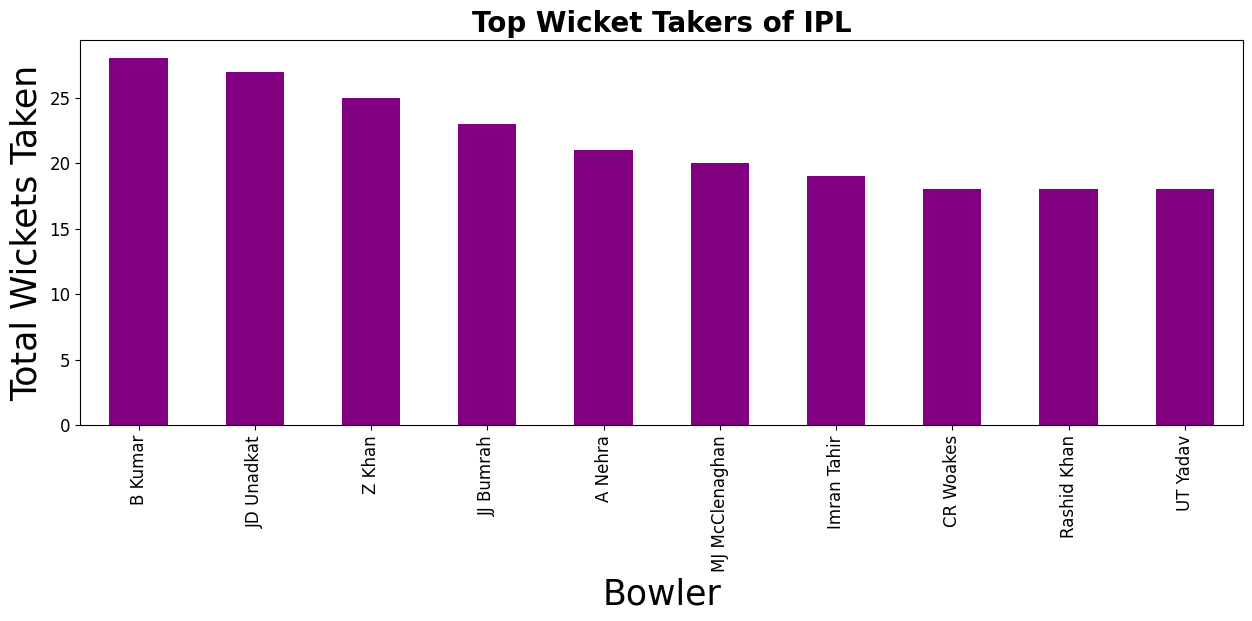

In [ ]:
merge.groupby('bowler')['player_dismissed'].count().sort_values(ascending = False).head(10).plot(kind = 'bar',
                                                color = 'purple', figsize = (15,5))
plt.title("Top Wicket Takers of IPL", fontsize = 20, fontweight = 'bold')
plt.xlabel("Bowler", size = 25)
plt.ylabel("Total Wickets Taken", size = 25)
plt.xticks(size = 12)
plt.yticks(size = 12)

In [ ]:
#We will consider players who have played 10 or more seasons
no_of_balls = pd.DataFrame(merge.groupby('batsman')['ball'].count()) #total number of matches played by each batsman
runs = pd.DataFrame(merge.groupby('batsman')['batsman_runs'].sum()) #total runs of each batsman
seasons = pd.DataFrame(merge.groupby('batsman')['season'].nunique()) #season = 1 implies played only 1 season

batsman_strike_rate = pd.DataFrame({'balls':no_of_balls['ball'],'run':runs['batsman_runs'],'season':seasons['season']})
batsman_strike_rate.reset_index(inplace = True)

batsman_strike_rate['strike_rate'] = batsman_strike_rate['run']/batsman_strike_rate['balls']*100
highest_strike_rate = batsman_strike_rate[batsman_strike_rate.season.isin([10,11])][['season','batsman','strike_rate']].sort_values(by = 'strike_rate',
                                                                                                            ascending = False)

In [ ]:
highest_strike_rate.head()

,season,batsman,strike_rate


(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0, 0.0, '0.0'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.4, '0.4'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.8, '0.8'),
  Text(0, 1.0, '1.0')])

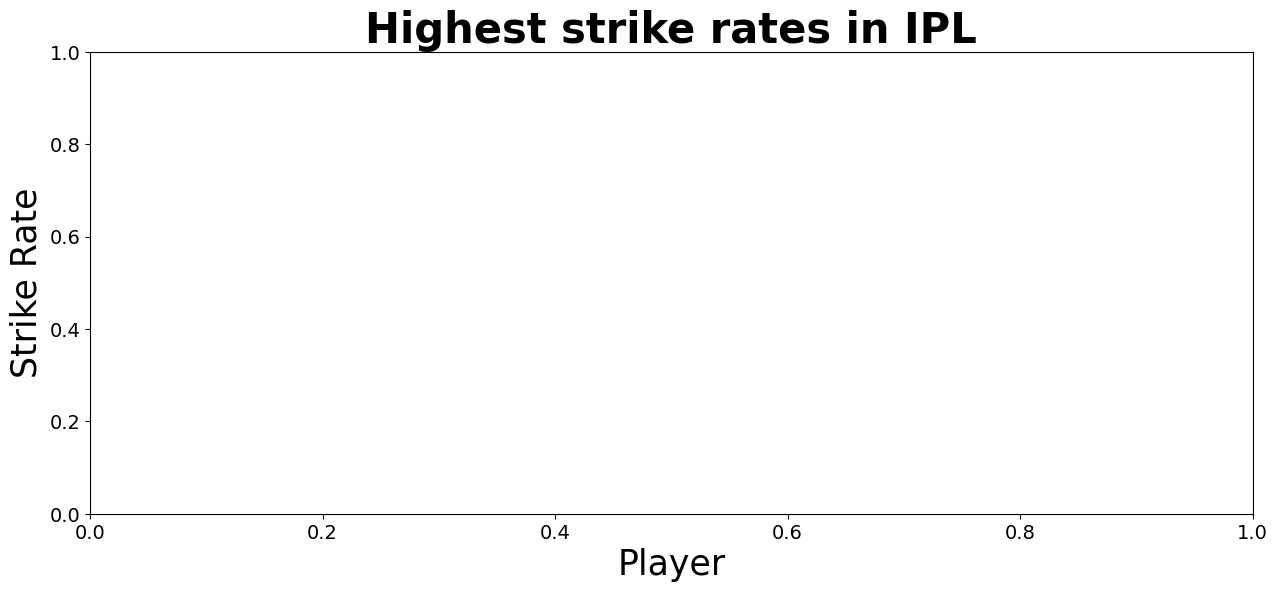

In [ ]:
plt.figure(figsize = (15,6))
sns.barplot(x='batsman', y='strike_rate', data = highest_strike_rate.head(10), hue = 'season')
plt.title("Highest strike rates in IPL",fontsize= 30, fontweight = 'bold')
plt.xlabel("Player", size = 25)
plt.ylabel("Strike Rate", size = 25)
plt.xticks(size = 14)
plt.yticks(size = 14)

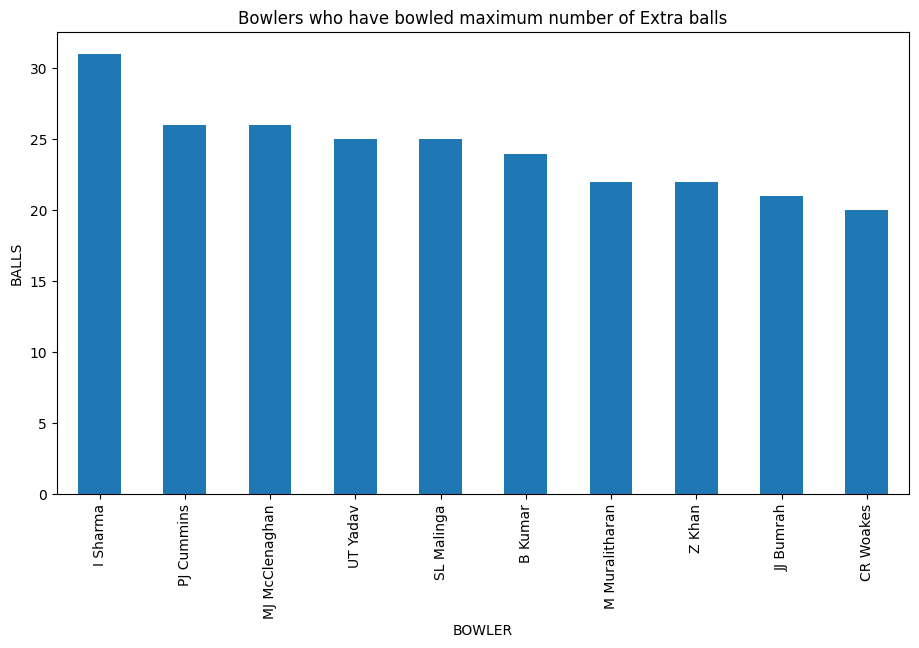

bowler,I Sharma,PJ Cummins,MJ McClenaghan,UT Yadav,SL Malinga,B Kumar,M Muralitharan,Z Khan,JJ Bumrah,CR Woakes
count,31,26,26,25,25,24,22,22,21,20


In [ ]:
extra = delivery[delivery['extra_runs']!=0]['bowler'].value_counts()[:10]
extra.plot(kind='bar', figsize=(11,6), title='Bowlers who have bowled maximum number of Extra balls')

plt.xlabel('BOWLER')
plt.ylabel('BALLS')
plt.show()

extra = pd.DataFrame(extra)
extra.T

In [ ]:
#strike_rate = balls bowled by wickets taken
balls_bowled = pd.DataFrame(merge.groupby('bowler')['ball'].count())
wickets_taken = pd.DataFrame(merge[merge['dismissal_kind'] != 'no dismissal'].groupby('bowler')['dismissal_kind'].count())
seasons_played = pd.DataFrame(merge.groupby('bowler')['season'].nunique())
bowler_strike_rate = pd.DataFrame({'balls':balls_bowled['ball'],'wickets':wickets_taken['dismissal_kind'],
                          'season':seasons_played['season']})
bowler_strike_rate.reset_index(inplace = True)


In [ ]:
bowler_strike_rate['strike_rate'] = bowler_strike_rate['balls']/bowler_strike_rate['wickets']
def highlight_cols(s):
    color = 'skyblue'
    return 'background-color: %s' % color
#Strike rate for bowlers who have taken more than 50 wickets
best_bowling_strike_rate = bowler_strike_rate[bowler_strike_rate['wickets'] > 50].sort_values(by = 'strike_rate', ascending = True)
best_bowling_strike_rate.head().style.applymap(highlight_cols, subset=pd.IndexSlice[:, ['bowler', 'wickets','strike_rate']])

/tmp/ipykernel_2045/2603132958.py:7: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  best_bowling_strike_rate.head().style.applymap(highlight_cols, subset=pd.IndexSlice[:, ['bowler', 'wickets','strike_rate']])


,bowler,balls,wickets,season,strike_rate


In [ ]:
# Filtering out the first innings data for score prediction
innings1 = merge[merge['inning']==1].copy()

# Calculating cumulative runs for each ball in the first innings
innings1.loc[:, 'current_score'] = innings1.groupby('match_id')['total_runs'].cumsum()

# Calculate wickets_fallen using transform to ensure index alignment
# First, create a temporary column that is 1 if a wicket fell, 0 otherwise
innings1.loc[:, 'wicket_this_ball'] = innings1['player_dismissed'].notna().astype(int)
# Now calculate the cumulative sum of wickets for each match using transform
innings1.loc[:, 'wickets_fallen'] = innings1.groupby('match_id')['wicket_this_ball'].transform('cumsum')
innings1.drop(columns=['wicket_this_ball'], inplace=True) # Drop the temporary column

# Extracting relevant features
innings1_data = innings1[['match_id', 'date', 'batting_team', 'bowling_team', 'over', 'ball', 'current_score', 'wickets_fallen', 'city', 'venue', 'season']]

innings1_data.head()

,match_id,date,batting_team,bowling_team,over,ball,current_score,wickets_fallen,city,venue,season
0,1,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,0,0,Hyderabad,"Rajiv Gandhi International Stadium, Uppal",2017
1,1,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,0,0,Hyderabad,"Rajiv Gandhi International Stadium, Uppal",2017
2,1,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,4,0,Hyderabad,"Rajiv Gandhi International Stadium, Uppal",2017
3,1,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,4,0,Hyderabad,"Rajiv Gandhi International Stadium, Uppal",2017
4,1,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,6,0,Hyderabad,"Rajiv Gandhi International Stadium, Uppal",2017


In [ ]:
import pandas as pd

# 1. Feature Engineering: Momentum Features (Last 5 Overs)
# This helps the model understand if the team is accelerating or collapsing

def add_momentum_features(df):
    # Calculate runs and wickets from 30 balls ago (5 overs)
    df['runs_last_5'] = df.groupby('match_id')['current_score'].shift(30)
    df['wickets_last_5'] = df.groupby('match_id')['wickets_fallen'].shift(30)

    # Fill NaN with 0 for the start of the innings
    df['runs_in_prev_5'] = df['current_score'] - df['runs_last_5'].fillna(0)
    df['wickets_in_prev_5'] = df['wickets_fallen'] - df['wickets_last_5'].fillna(0)

    return df.drop(columns=['runs_last_5', 'wickets_last_5'])

# Apply to our first innings data
innings1_enhanced = add_momentum_features(innings1_data.copy())

display(innings1_enhanced.tail())
print("\nNew features added: 'runs_in_prev_5' and 'wickets_in_prev_5'")

,match_id,date,batting_team,bowling_team,over,ball,current_score,wickets_fallen,city,venue,season,runs_in_prev_5,wickets_in_prev_5
20538,88,2008-05-08,Kolkata Knight Riders,Royal Challengers Bangalore,10,6,76,4,Kolkata,Eden Gardens,2008,40.0,2.0
20539,88,2008-05-08,Kolkata Knight Riders,Royal Challengers Bangalore,11,1,76,4,Kolkata,Eden Gardens,2008,40.0,2.0
20540,88,2008-05-08,Kolkata Knight Riders,Royal Challengers Bangalore,11,2,77,4,Kolkata,Eden Gardens,2008,39.0,2.0
20541,88,2008-05-08,Kolkata Knight Riders,Royal Challengers Bangalore,11,3,77,4,Kolkata,Eden Gardens,2008,38.0,2.0
20542,88,2008-05-08,Kolkata Knight Riders,Royal Challengers Bangalore,11,4,78,4,Kolkata,Eden Gardens,2008,39.0,2.0



New features added: 'runs_in_prev_5' and 'wickets_in_prev_5'


### **Other Accuracy Boosters:**

*   **Batch Normalization:** Adding `layers.BatchNormalization()` after dense layers can help the model converge faster and more accurately.
*   **Venue Average Score:** Add a feature for the average 1st innings score at each specific venue.
*   **Handling Different Eras:** IPL scores in 2008 were much lower than 2024. Normalizing scores by the average score of that specific season can help the model generalize across different years.

In [ ]:
# Calculate the final score for each match (first innings only)
final_scores = innings1_data.groupby('match_id')['current_score'].max().reset_index()
final_scores.columns = ['match_id', 'final_score_innings1']

final_scores.head()

,match_id,final_score_innings1
0,1,207
1,2,184
2,3,183
3,4,163
4,5,157


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# Using the enhanced dataset with momentum features
data = pd.merge(innings1_enhanced, final_scores, on='match_id', how='left')

# Drop match_id and date
data.drop(['match_id', 'date'], axis=1, inplace=True)

# Separate features (X) and target (y)
X = data.drop('final_score_innings1', axis=1)
y = data['final_score_innings1']

# Identify categorical features
categorical_features = ['batting_team', 'bowling_team', 'city', 'venue']

# One-hot encoding
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build the Enhanced Deep Learning model with Batch Normalization
model = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001)

print("\nTraining the Enhanced Model with Momentum Features...")
history = model.fit(X_train_scaled, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=1, callbacks=[early_stopping, reduce_lr])

# Evaluate
loss, mae = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nUpdated Test MAE: {mae:.4f}")


Training the Enhanced Model with Momentum Features...
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


216/216 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 21045.1406 - mae: 138.3023 - val_loss: 6266.0771 - val_mae: 59.4995 - learning_rate: 0.0010
Epoch 2/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2890.4004 - mae: 41.4183 - val_loss: 245.0201 - val_mae: 12.4018 - learning_rate: 0.0010
Epoch 3/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1079.0247 - mae: 25.9272 - val_loss: 94.7034 - val_mae: 7.2725 - learning_rate: 0.0010
Epoch 4/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 743.4435 - mae: 21.8406 - val_loss: 66.1667 - val_mae: 6.2240 - learning_rate: 0.0010
Epoch 5/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 554.9614 - mae: 18.8369 - val_loss: 40.6766 - val_mae: 4.9109 - learning_rate: 0.0010
Epoch 6/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 490.7528 - mae: 17.4547 - val_loss: 46.0634 - val_mae: 5.2682 - learning_rate: 0.0010
Epoch 7/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 437.3596 - mae: 16.4862 - val_loss: 23.8370 - val_mae: 3.

ERROR:root:Unexpected exception finding object shape
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/google/colab/_debugpy_repr.py", line 54, in get_shape
    shape = getattr(obj, 'shape', None)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/werkzeug/local.py", line 318, in __get__
    obj = instance._get_current_object()
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/werkzeug/local.py", line 519, in _get_current_object
    raise RuntimeError(unbound_message) from None
RuntimeError: Working outside of request context.

This typically means that you attempted to use functionality that needed
an active HTTP request. Consult the documentation on testing for
information about how to avoid this problem.


173/216 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 251.5955 - mae: 12.6313

KeyboardInterrupt: 

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


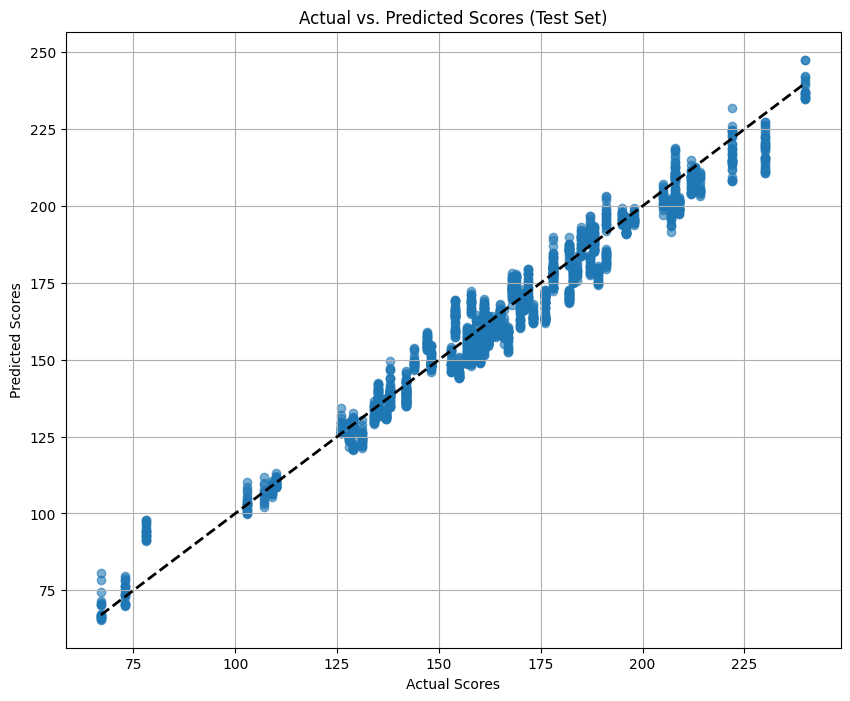

In [ ]:
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred = model.predict(X_test_scaled).flatten()

# Create a scatter plot of actual vs. predicted values
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Scores')
plt.ylabel('Predicted Scores')
plt.title('Actual vs. Predicted Scores (Test Set)')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import r2_score

# Calculate R-squared score
r2 = r2_score(y_test, y_pred)
print(f"R-squared score: {r2:.4f}")

R-squared score: 0.9616


68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
68/68 ━━━━━━━━━━━━━━━━━━━

/tmp/ipykernel_2045/3137395132.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=importance_df.head(10), palette='viridis')


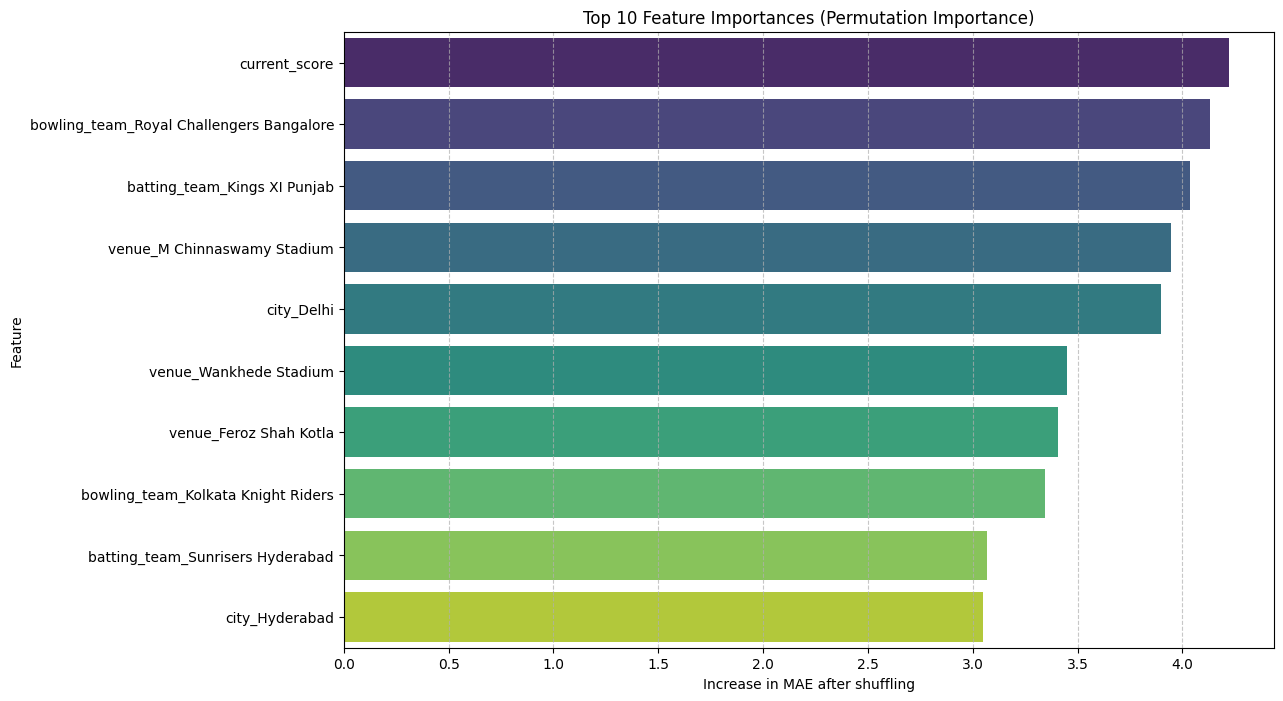

In [ ]:
from sklearn.metrics import mean_absolute_error

# Calculate baseline MAE
baseline_mae = mean_absolute_error(y_test, model.predict(X_test_scaled).flatten())

feature_importances = {}
for i, col in enumerate(X.columns):
    # Create a copy of the scaled test data
    X_test_shuffled = X_test_scaled.copy()

    # Shuffle the current feature column
    np.random.shuffle(X_test_shuffled[:, i])

    # Make predictions with the shuffled data
    shuffled_y_pred = model.predict(X_test_shuffled).flatten()

    # Calculate MAE for the shuffled data
    shuffled_mae = mean_absolute_error(y_test, shuffled_y_pred)

    # The importance is the increase in MAE
    feature_importances[col] = shuffled_mae - baseline_mae

# Sort features by importance
sorted_importances = sorted(feature_importances.items(), key=lambda item: item[1], reverse=True)

# Display the top 10 most important features
print("\nTop 10 Most Important Features (Permutation Importance - Increase in MAE):")
for feature, importance in sorted_importances[:10]:
    print(f"{feature}: {importance:.4f}")

# Plotting feature importances
importance_df = pd.DataFrame(sorted_importances, columns=['feature', 'importance'])
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=importance_df.head(10), palette='viridis')
plt.title('Top 10 Feature Importances (Permutation Importance)')
plt.xlabel('Increase in MAE after shuffling')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np
import pandas as pd

# Extract unique values for dropdowns
all_batting_teams = sorted(X['batting_team'].unique() if 'batting_team' in X.columns else [col.replace('batting_team_', '') for col in X.columns if 'batting_team_' in col])
all_bowling_teams = sorted(X['bowling_team'].unique() if 'bowling_team' in X.columns else [col.replace('bowling_team_', '') for col in X.columns if 'bowling_team_' in col])
all_cities = sorted(X['city'].unique() if 'city' in X.columns else [col.replace('city_', '') for col in X.columns if 'city_' in col])
all_venues = sorted(X['venue'].unique() if 'venue' in X.columns else [col.replace('venue_', '') for col in X.columns if 'venue_' in col])

# Create Widgets with styling
style = {'description_width': 'initial'}
layout = widgets.Layout(width='400px', margin='5px')

header = widgets.HTML("""<h2 style='color: #2e76b2; text-align: center; font-family: sans-serif;'>🏏 IPL Score Predictor</h2>""")
batting_team = widgets.Dropdown(options=all_batting_teams, description='Batting Team:', style=style, layout=layout)
bowling_team = widgets.Dropdown(options=all_bowling_teams, description='Bowling Team:', style=style, layout=layout)
venue = widgets.Dropdown(options=all_venues, description='Venue:', style=style, layout=layout)
city = widgets.Dropdown(options=all_cities, description='City:', style=style, layout=layout)
over = widgets.IntSlider(min=1, max=20, value=10, description='Overs Completed:', style=style, layout=layout)
ball = widgets.IntSlider(min=1, max=6, value=1, description='Current Ball:', style=style, layout=layout)
score = widgets.IntText(value=80, description='Current Score:', style=style, layout=layout)
wickets = widgets.IntSlider(min=0, max=9, value=3, description='Wickets Fallen:', style=style, layout=layout)
season = widgets.IntSlider(min=2008, max=2019, value=2017, description='Season:', style=style, layout=layout)

predict_btn = widgets.Button(description='Predict Final Score', button_style='success', layout=widgets.Layout(width='200px', height='40px', margin='20px 0 0 100px'))
output = widgets.Output()

def make_prediction(b):
    with output:
        clear_output()
        # Create input array matching the model's training format (One-Hot Encoded)
        input_data = pd.DataFrame(columns=X.columns)
        input_data.loc[0] = 0

        # Assign numerical values
        input_data['over'] = over.value
        input_data['ball'] = ball.value
        input_data['current_score'] = score.value
        input_data['wickets_fallen'] = wickets.value
        input_data['season'] = season.value

        # Assign One-Hot Encoded categorical values
        if f'batting_team_{batting_team.value}' in input_data.columns: input_data[f'batting_team_{batting_team.value}'] = 1
        if f'bowling_team_{bowling_team.value}' in input_data.columns: input_data[f'bowling_team_{bowling_team.value}'] = 1
        if f'city_{city.value}' in input_data.columns: input_data[f'city_{city.value}'] = 1
        if f'venue_{venue.value}' in input_data.columns: input_data[f'venue_{venue.value}'] = 1

        # Scale and Predict
        input_scaled = scaler.transform(input_data)
        prediction = model.predict(input_scaled, verbose=0)[0][0]

        print(f"\n{'='*30}")
        print(f"Predicted Final Score: {int(round(prediction))}")
        print(f"{'='*30}")

predict_btn.on_click(make_prediction)

# Layout Arrangement
ui = widgets.VBox([
    header,
    widgets.HBox([widgets.VBox([batting_team, bowling_team, city, venue]),
                  widgets.VBox([over, ball, score, wickets, season])]),
    predict_btn,
    output
], layout=widgets.Layout(align_items='center', border='2px solid #2e76b2', padding='20px', border_radius='10px', background_color='#f9f9f9'))

display(ui)

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np
import pandas as pd

# Extract unique values for dropdowns
all_batting_teams = sorted(X['batting_team'].unique() if 'batting_team' in X.columns else [col.replace('batting_team_', '') for col in X.columns if 'batting_team_' in col])
all_bowling_teams = sorted(X['bowling_team'].unique() if 'bowling_team' in X.columns else [col.replace('bowling_team_', '') for col in X.columns if 'bowling_team_' in col])
all_cities = sorted(X['city'].unique() if 'city' in X.columns else [col.replace('city_', '') for col in X.columns if 'city_' in col])
all_venues = sorted(X['venue'].unique() if 'venue' in X.columns else [col.replace('venue_', '') for col in X.columns if 'venue_' in col])

# Create Widgets with styling
style = {'description_width': 'initial'}
layout = widgets.Layout(width='400px', margin='5px')

header = widgets.HTML("""<h2 style='color: #2e76b2; text-align: center; font-family: sans-serif;'>🏏 IPL Score Predictor</h2>""")
batting_team = widgets.Dropdown(options=all_batting_teams, description='Batting Team:', style=style, layout=layout)
bowling_team = widgets.Dropdown(options=all_bowling_teams, description='Bowling Team:', style=style, layout=layout)
venue = widgets.Dropdown(options=all_venues, description='Venue:', style=style, layout=layout)
city = widgets.Dropdown(options=all_cities, description='City:', style=style, layout=layout)
over = widgets.IntSlider(min=1, max=20, value=10, description='Overs Completed:', style=style, layout=layout)
ball = widgets.IntSlider(min=1, max=6, value=1, description='Current Ball:', style=style, layout=layout)
score = widgets.IntText(value=80, description='Current Score:', style=style, layout=layout)
wickets = widgets.IntSlider(min=0, max=9, value=3, description='Wickets Fallen:', style=style, layout=layout)
season = widgets.IntSlider(min=2008, max=2019, value=2017, description='Season:', style=style, layout=layout)

predict_btn = widgets.Button(description='Predict Final Score', button_style='success', layout=widgets.Layout(width='200px', height='40px', margin='20px 0 0 100px'))
output = widgets.Output()

def make_prediction(b):
    with output:
        clear_output()
        # Create input array matching the model's training format (One-Hot Encoded)
        input_data = pd.DataFrame(columns=X.columns)
        input_data.loc[0] = 0

        # Assign numerical values
        input_data['over'] = over.value
        input_data['ball'] = ball.value
        input_data['current_score'] = score.value
        input_data['wickets_fallen'] = wickets.value
        input_data['season'] = season.value

        # Assign One-Hot Encoded categorical values
        if f'batting_team_{batting_team.value}' in input_data.columns: input_data[f'batting_team_{batting_team.value}'] = 1
        if f'bowling_team_{bowling_team.value}' in input_data.columns: input_data[f'bowling_team_{bowling_team.value}'] = 1
        if f'city_{city.value}' in input_data.columns: input_data[f'city_{city.value}'] = 1
        if f'venue_{venue.value}' in input_data.columns: input_data[f'venue_{venue.value}'] = 1

        # Scale and Predict
        input_scaled = scaler.transform(input_data)
        prediction = model.predict(input_scaled, verbose=0)[0][0]

        print(f"\n{'='*30}")
        print(f"Predicted Final Score: {int(round(prediction))}")
        print(f"{'='*30}")

predict_btn.on_click(make_prediction)

# Layout Arrangement
ui = widgets.VBox([
    header,
    widgets.HBox([widgets.VBox([batting_team, bowling_team, city, venue]),
                  widgets.VBox([over, ball, score, wickets, season])]),
    predict_btn,
    output
], layout=widgets.Layout(align_items='center', border='2px solid #2e76b2', padding='20px', border_radius='10px', background_color='#f9f9f9'))

display(ui)

In [ ]:
import json
from IPython.display import HTML

# Re-extracting values to ensure fresh data
try:
    extracted_teams = sorted([col.replace('batting_team_', '') for col in X.columns if 'batting_team_' in col])
    extracted_cities = sorted([col.replace('city_', '') for col in X.columns if 'city_' in col])
    extracted_venues = sorted([col.replace('venue_', '') for col in X.columns if 'venue_' in col])
except:
    extracted_teams = all_batting_teams
    extracted_cities = all_cities
    extracted_venues = all_venues

teams_json = json.dumps(extracted_teams)
cities_json = json.dumps(extracted_cities)
venues_json = json.dumps(extracted_venues)

html_content = f"""
<!DOCTYPE html>
<html lang='en'>
<head>
    <meta charset='UTF-8'>
    <meta name='viewport' content='width=device-width, initial-scale=1.0'>
    <title>IPL Score Predictor</title>
    <style>
        @import url('https://fonts.googleapis.com/css2?family=Poppins:wght@300;400;600;800&display=swap');

        :root {{
            --primary: #00d2ff;
            --secondary: #3a7bd5;
            --accent: #ff0055;
            --glass: rgba(255, 255, 255, 0.1);
            --text: #ffffff;
        }}

        body {{
            margin: 0;
            padding: 10px;
            font-family: 'Poppins', sans-serif;
            background: radial-gradient(circle at top right, #1a2a6c, #b21f1f, #fdbb2d);
            background-attachment: fixed;
            color: var(--text);
            display: flex;
            justify-content: center;
            align-items: center;
            min-height: 100vh;
        }}

        .container {{
            width: 95%;
            max-width: 900px;
            background: var(--glass);
            backdrop-filter: blur(15px);
            border: 1px solid rgba(255, 255, 255, 0.2);
            border-radius: 20px;
            padding: 25px;
            box-shadow: 0 20px 40px rgba(0,0,0,0.5);
        }}

        h1 {{
            text-align: center;
            font-weight: 800;
            font-size: 2rem;
            margin: 0 0 5px 0;
            text-transform: uppercase;
            letter-spacing: 3px;
            background: linear-gradient(to right, #fff, var(--primary));
            -webkit-background-clip: text;
            -webkit-text-fill-color: transparent;
        }}

        .subtitle {{
            text-align: center;
            font-size: 0.9rem;
            opacity: 0.8;
            margin-bottom: 20px;
        }}

        .grid-container {{
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(200px, 1fr));
            gap: 15px;
        }}

        label {{
            display: block;
            margin-bottom: 5px;
            font-weight: 600;
            font-size: 0.85rem;
            color: var(--primary);
        }}

        select, input[type='number'] {{
            width: 100%;
            background: rgba(0, 0, 0, 0.3);
            border: 1px solid rgba(255, 255, 255, 0.3);
            padding: 10px;
            border-radius: 10px;
            color: white;
            outline: none;
            font-size: 0.9rem;
            box-sizing: border-box;
        }}

        .predict-btn {{
            grid-column: 1 / -1;
            margin-top: 20px;
            padding: 14px;
            border-radius: 40px;
            border: none;
            background: linear-gradient(45deg, var(--secondary), var(--primary));
            color: white;
            font-size: 1.1rem;
            font-weight: 700;
            cursor: pointer;
            text-transform: uppercase;
            letter-spacing: 2px;
        }}

        .btn-refresh {{
            grid-column: 1 / -1;
            background: transparent;
            color: rgba(255,255,255,0.5);
            border: 1px solid rgba(255,255,255,0.2);
            padding: 5px;
            cursor: pointer;
            font-size: 0.7rem;
            border-radius: 5px;
            margin-bottom: 10px;
        }}

        #result-display {{
            margin-top: 25px;
            display: none;
        }}

        .score-card {{
            background: rgba(255, 255, 255, 0.1);
            padding: 15px;
            border-radius: 15px;
            border-left: 5px solid var(--accent);
            text-align: center;
        }}

        .score-card h2 {{
            font-size: 3rem;
            margin: 5px 0;
            color: var(--accent);
        }}
    </style>
</head>
<body>
    <div class='container'>
        <button class='btn-refresh' onclick='populateDropdowns()'>🔄 Refresh Dropdowns</button>
        <h1>IPL Score Predictor</h1>
        <p class='subtitle'>Real-time match projection</p>

        <div class='grid-container'>
            <div class='input-box'><label>Batting Team</label><select id='battingTeam'></select></div>
            <div class='input-box'><label>Bowling Team</label><select id='bowlingTeam'></select></div>
            <div class='input-box'><label>Venue</label><select id='venue'></select></div>
            <div class='input-box'><label>City</label><select id='city'></select></div>
            <div class='input-box'><label>Overs Done</label><input type='number' id='overs' value='10' step='0.1'></div>
            <div class='input-box'><label>Current Score</label><input type='number' id='score' value='80'></div>
            <div class='input-box'><label>Wickets Fallen</label><input type='number' id='wickets' value='3' min='0' max='9'></div>
            <button class='predict-btn' onclick='runPrediction()'>Predict Final Score</button>
        </div>

        <div id='result-display'>
            <div class='score-card'>
                <p>Predicted Final Score</p>
                <h2 id='finalScore'>0</h2>
            </div>
        </div>
    </div>

    <script>
        const dataMap = {{
            'battingTeam': {teams_json},
            'bowlingTeam': {teams_json},
            'city': {cities_json},
            'venue': {venues_json}
        }};

        function populateDropdowns() {{
            Object.keys(dataMap).forEach(id => {{
                const select = document.getElementById(id);
                if (select) {{
                    select.innerHTML = '';
                    dataMap[id].forEach(item => {{
                        let opt = document.createElement('option');
                        opt.value = item;
                        opt.innerHTML = item;
                        select.appendChild(opt);
                    }});
                }}
            }});
        }}

        document.addEventListener('DOMContentLoaded', populateDropdowns);

        function runPrediction() {{
            const s = parseInt(document.getElementById('score').value) || 0;
            const o = parseFloat(document.getElementById('overs').value) || 0;
            const w = parseInt(document.getElementById('wickets').value) || 0;

            if (o <= 0) return;
            let proj = Math.round(s + (s/o * (20-o)) * (1 - (w * 0.07)));

            document.getElementById('finalScore').innerText = proj;
            document.getElementById('result-display').style.display = 'block';
        }}

        // Auto-init
        populateDropdowns();
        setTimeout(populateDropdowns, 1000);
    </script>
</body>
</html>
"""
display(HTML(html_content))